In [23]:
# environment_version = "6"
# dependencies = [
#   "numpy==2.4.6",
#   "pandas<3.0",
#   "scipy==1.17.1",
#   "scikit-learn==1.9.0",
#   "joblib==1.5.3",
#   "matplotlib==3.11.0",
# ]
# MAGIC %md
# MAGIC # 07 - Logistic Regression | Member 1
# MAGIC ## 1. What I am doing
# MAGIC Train and evaluate Logistic Regression using the shared chronological data split.
# MAGIC ## 2. Why I am doing it
# MAGIC A linear multiclass baseline gives an interpretable comparison. Numeric centering/scaling is fitted on training only; one-hot features remain sparse.

## 3. Install notebook libraries
Run on Databricks serverless notebook compute using Python 3.11 or newer.
Dependencies are installed directly in this cell; no separate setup file is needed.
Use the same pinned versions in every Member 4 notebook.
Run the restart cell immediately after installation, then continue with Imports.

%pip install numpy==2.4.6 scipy==1.17.1 scikit-learn==1.9.0 joblib==1.5.3 matplotlib==3.11.0
%pip install "pandas<3.0"

In [24]:
if 'dbutils' in globals() and hasattr(dbutils, 'library'):
    dbutils.library.restartPython()


## 4. Imports

In [25]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import time
import uuid
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, FunctionTransformer

In [26]:
import pandas as pd
import pyspark

# Initialize Spark Session if not already present
if 'spark' not in globals() or spark is None:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.appName('07_Logistic_Regression').master('local[*]').getOrCreate()

print("Pandas:", pd.__version__)
print("PySpark:", pyspark.__version__)


d:\Projects\Chicago_Crime_Prediction\.venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Pandas: 3.0.6
PySpark: 4.2.0


## 5. Databricks table, artifact location and split configuration
Keep these settings identical in all Member 4 notebooks.
Train: before July 2025; validation: July-December 2025; test: from January 2026.
The first baseline run freezes the clean-table snapshot in a shared volume.
Later notebooks reuse the same data and fitted preprocessing.
Change EXPERIMENT everywhere to intentionally start a new experiment.

In [27]:
CATALOG_SCHEMA = 'workspace.default'
SOURCE_TABLE = f'{CATALOG_SCHEMA}.chicago_crime_clean'
VOLUME_NAME = 'chicago_crime_member4'
ARTIFACT_ROOT = Path(f'/Volumes/workspace/default/{VOLUME_NAME}')
EXPERIMENT = 'member4_v1'
SEED = 42
MAX_LOCAL_ROWS = 750000
TRAIN_END = '2025-07-01'
VALIDATION_END = '2026-01-01'
MODEL_NAMES = ['Logistic_Regression', 'Decision_Tree', 'Random_Forest', 'XGBoost']
RAW_FEATURES = ['date', 'location_description', 'beat', 'district', 'ward', 'community_area', 'latitude', 'longitude', 'domestic']
CATEGORICAL = ['location_description', 'beat', 'district', 'ward', 'community_area', 'area_group']
NUMERIC = ['latitude', 'longitude', 'year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'is_weekend', 'domestic_int', 'coordinates_missing']
LEAKAGE_EXCLUSIONS = ['iucr', 'description', 'fbi_code', 'arrest', 'updated_on', 'case_number']

## 6. Local data and evaluation functions
These cells define the functions used by this notebook. Execute them from top to bottom.
All required code is included here; there are no imports from another project notebook.

In [28]:
def experiment_dir():
    try:
        if ARTIFACT_ROOT.exists() or str(ARTIFACT_ROOT).startswith('/Volumes'):
            exp = ARTIFACT_ROOT / EXPERIMENT
            exp.mkdir(parents=True, exist_ok=True)
            return exp
    except Exception:
        pass
    # Local fallback path
    curr = Path.cwd().resolve()
    for p in [curr] + list(curr.parents):
        if (p / 'databricks').exists():
            exp = p / 'databricks' / 'artifacts' / VOLUME_NAME / EXPERIMENT
            exp.mkdir(parents=True, exist_ok=True)
            return exp
    exp = curr / 'artifacts' / VOLUME_NAME / EXPERIMENT
    exp.mkdir(parents=True, exist_ok=True)
    return exp


In [29]:
def save_json(path, value):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False), encoding="utf-8")

In [30]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

In [31]:
def versions():
    return {p: importlib.metadata.version(p) for p in
            ["numpy", "pandas", "scipy", "scikit-learn", "joblib", "matplotlib"]}

In [32]:
def configuration():
    return dict(source_table=SOURCE_TABLE, train_end=TRAIN_END, validation_end=VALIDATION_END,
                seed=SEED, raw_features=RAW_FEATURES, categorical=CATEGORICAL, numeric=NUMERIC,
                preprocessing_version=1)

In [33]:
def load_manifest():
    path = experiment_dir() / "manifest.json"
    if not path.exists():
        raise RuntimeError("Run a baseline notebook (07-10) to prepare the shared data first.")
    manifest = read_json(path)
    if manifest["configuration"] != configuration():
        raise ValueError("Configuration changed. Use a new EXPERIMENT and prepare data again.")
    if manifest["versions"] != versions():
        raise ValueError("Package versions differ from preparation. Use the saved environment versions.")
    return manifest

In [34]:
def engineer_features(raw, coordinate_medians):
    """Identical deterministic transformation for training and backend prediction."""
    missing = set(RAW_FEATURES) - set(raw.columns)
    if missing:
        raise ValueError(f"Missing input columns: {sorted(missing)}")
    x = raw[RAW_FEATURES].copy()
    dates = pd.to_datetime(x["date"], errors="coerce")
    if dates.isna().any() or dates.dt.tz is not None:
        raise ValueError("date must contain valid timezone-naive Chicago incident timestamps.")
    x["year"] = dates.dt.year
    hour, weekday, month = dates.dt.hour, dates.dt.dayofweek, dates.dt.month
    for name, values, period in [("hour", hour, 24), ("day_of_week", weekday, 7), ("month", month - 1, 12)]:
        x[f"{name}_sin"] = np.sin(2 * np.pi * values / period)
        x[f"{name}_cos"] = np.cos(2 * np.pi * values / period)
    x["is_weekend"] = (weekday >= 5).astype(int)
    domestic = x["domestic"].astype("string").str.lower().str.strip()
    if not domestic.dropna().isin(["true", "false", "1", "0", "1.0", "0.0"]).all():
        raise ValueError("domestic must be a Boolean, 0/1, or missing.")
    # Matches Member 3: missing domestic is mapped to 0.
    x["domestic_int"] = domestic.isin(["true", "1", "1.0"]).astype(int)
    for col in ["latitude", "longitude"]:
        x[col] = pd.to_numeric(x[col], errors="raise").astype(float)
        if np.isinf(x[col]).any():
            raise ValueError(f"Infinite {col} values are invalid.")
    absent = x[["latitude", "longitude"]].isna().any(axis=1)
    x["coordinates_missing"] = absent.astype(int)
    north = x["latitude"] >= coordinate_medians["latitude"]
    west = x["longitude"] < coordinate_medians["longitude"]
    x["area_group"] = np.select(
        [absent, north & west, north & ~west, ~north & west],
        ["Unknown", "North-West", "North-East", "South-West"], default="South-East",
    )
    for col in CATEGORICAL:
        if col in ["beat", "district", "ward", "community_area"]:
            codes = pd.to_numeric(x[col], errors="raise")
            if (codes.dropna() % 1 != 0).any():
                raise ValueError(f"{col} must contain whole-number geographic codes.")
            x[col] = codes.astype("Int64").astype("string")
        x[col] = x[col].astype("string").fillna("Unknown").astype(str)
    return x[CATEGORICAL + NUMERIC]

In [35]:
import os
import json
import shutil
import tempfile
from pathlib import Path

def prepare_frame(frame, output, source_description):
    """
    Prepare the shared snapshot using local /tmp storage first,
    then copy completed artifacts to the Databricks Volume.

    This avoids filesystem operations that can raise:
    OSError: [Errno 95] Operation not supported
    on /Volumes paths.
    """

    output = Path(output)

    # ---------------------------------------------------------
    # 1. Validate input
    # ---------------------------------------------------------
    print("Validating source data...")

    data = frame.copy()

    required = [
        "unique_key",
        "primary_type"
    ] + RAW_FEATURES

    missing = set(required) - set(data.columns)

    if missing:
        raise ValueError(
            f"Source table is missing: {sorted(missing)}"
        )

    if (
        data["unique_key"].isna().any()
        or data["unique_key"].duplicated().any()
    ):
        raise ValueError(
            "unique_key must be non-null and unique; "
            "review Member 1 cleaning."
        )

    if (
        data["primary_type"].isna().any()
        or data["primary_type"]
            .astype(str)
            .str.strip()
            .eq("")
            .any()
    ):
        raise ValueError(
            "Missing target labels must be resolved before modelling."
        )

    # ---------------------------------------------------------
    # 2. Parse and validate dates
    # ---------------------------------------------------------
    print("Processing dates...")

    data["date"] = pd.to_datetime(
        data["date"],
        errors="coerce"
    )

    if (
        data["date"].isna().any()
        or data["date"].dt.tz is not None
    ):
        raise ValueError(
            "Source date must be a valid timezone-naive "
            "incident timestamp."
        )

    data = (
        data
        .sort_values(["date", "unique_key"])
        .reset_index(drop=True)
    )

    # ---------------------------------------------------------
    # 3. Chronological split
    # ---------------------------------------------------------
    print("Creating chronological splits...")

    splits = {
        "train": data.loc[
            data["date"] < TRAIN_END
        ].copy(),

        "validation": data.loc[
            (data["date"] >= TRAIN_END)
            & (data["date"] < VALIDATION_END)
        ].copy(),

        "test": data.loc[
            data["date"] >= VALIDATION_END
        ].copy()
    }

    for split_name, part in splits.items():
        print(
            f"{split_name.title()} rows: "
            f"{len(part):,}"
        )

    if any(part.empty for part in splits.values()):
        raise ValueError(
            "A chronological split is empty. "
            "Review dates and agree new boundaries with the team."
        )

    train = splits["train"]

    # ---------------------------------------------------------
    # 4. Training-only coordinate medians
    # ---------------------------------------------------------
    print("Calculating training coordinate medians...")

    medians = {
        c: float(
            pd.to_numeric(
                train[c],
                errors="raise"
            ).median()
        )
        for c in ["latitude", "longitude"]
    }

    if not all(
        np.isfinite(v)
        for v in medians.values()
    ):
        raise ValueError(
            "Training coordinates cannot be "
            "entirely missing or infinite."
        )

    print("Coordinate medians:", medians)

    # ---------------------------------------------------------
    # 5. Build preprocessing pipeline
    # ---------------------------------------------------------
    print("Fitting preprocessing pipeline...")

    preprocessor = ColumnTransformer(
        [
            (
                "categories",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                    dtype=np.float32
                ),
                CATEGORICAL
            ),
            (
                "numbers",
                SimpleImputer(
                    strategy="median"
                ),
                NUMERIC
            ),
        ],
        sparse_threshold=1.0
    )

    train_features = engineer_features(
        train,
        medians
    )

    preprocessor.fit(train_features)

    # ---------------------------------------------------------
    # 6. Label encoder
    # ---------------------------------------------------------
    print("Encoding target labels...")

    labels = LabelEncoder().fit(
        train["primary_type"].astype(str)
    )

    if len(labels.classes_) < 2:
        raise ValueError(
            "Training requires at least two target classes."
        )

    mapping = {
        name: i
        for i, name in enumerate(labels.classes_)
    }

    print(
        "Target classes:",
        len(labels.classes_)
    )

    # ---------------------------------------------------------
    # 7. IMPORTANT:
    # Create LOCAL temporary directory.
    # Do not directly write joblib/numpy/scipy files to /Volumes.
    # ---------------------------------------------------------
    temp_root = Path(
        tempfile.mkdtemp(
            prefix="member4_snapshot_"
        )
    )

    print(
        "Temporary local directory:",
        temp_root
    )

    try:

        # -----------------------------------------------------
        # 8. Save preprocessing bundle locally
        # -----------------------------------------------------
        bundle = {
            "preprocessor": preprocessor,
            "coordinate_medians": medians,
            "classes": labels.classes_.tolist(),
            "raw_features": RAW_FEATURES,
            "feature_names":
                preprocessor
                .get_feature_names_out()
                .tolist()
        }

        print("Saving preprocessing bundle locally...")

        joblib.dump(
            bundle,
            temp_root / "preprocessing.joblib"
        )

        # -----------------------------------------------------
        # 9. Transform each split
        # -----------------------------------------------------
        coverage = {}

        digest = hashlib.sha256()

        for split, part in splits.items():

            print()
            print(
                f"Processing {split} split..."
            )

            engineered = engineer_features(
                part,
                medians
            )

            transformed = preprocessor.transform(
                engineered
            )

            features = sparse.csr_matrix(
                transformed,
                dtype=np.float32
            )

            if not np.isfinite(
                features.data
            ).all():
                raise ValueError(
                    f"Non-finite encoded features "
                    f"in {split}."
                )

            # ---------------------------------------------
            # Labels
            # ---------------------------------------------
            y = (
                part["primary_type"]
                .astype(str)
                .map(mapping)
                .fillna(-1)
                .to_numpy(dtype=np.int32)
            )

            if (
                split == "validation"
                and (y == -1).all()
            ):
                raise ValueError(
                    "No validation target classes "
                    "occur in training."
                )

            # ---------------------------------------------
            # Save LOCAL artifacts
            # ---------------------------------------------
            print(
                f"Saving {split} features locally..."
            )

            sparse.save_npz(
                temp_root /
                f"{split}_features.npz",
                features
            )

            np.save(
                temp_root /
                f"{split}_labels.npy",
                y
            )

            joblib.dump(
                part[required],
                temp_root /
                f"{split}_rows.joblib",
                compress=3
            )

            # ---------------------------------------------
            # Snapshot hash
            # ---------------------------------------------
            digest.update(
                pd.util.hash_pandas_object(
                    part[required],
                    index=False
                ).values.tobytes()
            )

            coverage[split] = {
                "rows": len(part),
                "start": str(
                    part["date"].min()
                ),
                "end": str(
                    part["date"].max()
                ),
                "unseen_target_rows":
                    int((y == -1).sum()),
                "features":
                    features.shape[1]
            }

            print(
                f"{split.title()} complete:",
                features.shape
            )

            # Release large temporary matrices
            del engineered
            del transformed
            del features
            del y

        # -----------------------------------------------------
        # 10. Build manifest
        # -----------------------------------------------------
        manifest = {
            "experiment_id":
                uuid.uuid4().hex,

            "configuration":
                configuration(),

            "source_description":
                source_description,

            "snapshot_sha256":
                digest.hexdigest(),

            "versions":
                versions(),

            "coverage":
                coverage,

            "classes":
                bundle["classes"],

            "coordinate_medians":
                medians,

            "feature_names":
                bundle["feature_names"],

            "leakage_exclusions":
                LEAKAGE_EXCLUSIONS
        }

        # -----------------------------------------------------
        # 11. Save manifest LOCALLY
        #
        # Manifest remains completion marker and therefore
        # is copied LAST.
        # -----------------------------------------------------
        local_manifest = (
            temp_root / "manifest.json"
        )

        with open(
            local_manifest,
            "w",
            encoding="utf-8"
        ) as f:
            json.dump(
                manifest,
                f,
                indent=2,
                allow_nan=False
            )

        # -----------------------------------------------------
        # 12. Create Volume destination
        # -----------------------------------------------------
        print()
        print(
            "Copying completed snapshot "
            "to Databricks Volume..."
        )

        os.makedirs(
            str(output),
            exist_ok=True
        )

        # -----------------------------------------------------
        # 13. Copy everything EXCEPT manifest first
        # -----------------------------------------------------
        local_files = [
            p
            for p in temp_root.iterdir()
            if p.name != "manifest.json"
        ]

        for local_file in local_files:

            destination = (
                output /
                local_file.name
            )

            print(
                "Copying:",
                local_file.name
            )

            shutil.copyfile(
                str(local_file),
                str(destination)
            )

        # -----------------------------------------------------
        # 14. Copy completion marker LAST
        # -----------------------------------------------------
        print(
            "Copying: manifest.json"
        )

        shutil.copyfile(
            str(local_manifest),
            str(
                output /
                "manifest.json"
            )
        )

        print()
        print(
            "All snapshot artifacts copied successfully."
        )

        return manifest

    finally:

        # -----------------------------------------------------
        # 15. Clean local temporary directory
        # -----------------------------------------------------
        print(
            "Cleaning temporary local files..."
        )

        shutil.rmtree(
            temp_root,
            ignore_errors=True
        )

In [36]:
import os
import pandas as pd

def prepare_databricks(spark=None):
    """
    Load the shared Databricks clean table and prepare the frozen
    Member 4 snapshot.
    """
    if spark is None:
        if 'spark' in globals() and spark is not None:
            spark = globals()['spark']
        else:
            from pyspark.sql import SparkSession
            spark = SparkSession.builder.appName('07_Logistic_Regression').master('local[*]').getOrCreate()

    exp_dir = experiment_dir()
    manifest_path = exp_dir / "manifest.json"

    # 1. Reuse existing prepared snapshot if available
    try:
        manifest_exists = os.path.exists(str(manifest_path))
    except OSError:
        manifest_exists = False

    if manifest_exists:
        print("Reusing frozen snapshot. Change EXPERIMENT to prepare a different snapshot.")
        return load_manifest()

    # 2. Check source table
    source = None
    for tbl in [SOURCE_TABLE, 'default.chicago_crime_clean', 'chicago_crime_clean']:
        try:
            if spark.catalog.tableExists(tbl):
                source = spark.table(tbl)
                break
        except Exception:
            pass

    if source is None:
        def locate_file(rel_path):
            curr = Path.cwd().resolve()
            for p in [curr] + list(curr.parents):
                candidate = p / rel_path
                if candidate.exists():
                    return str(candidate).replace('\\', '/')
            direct = Path('D:/Projects/Chicago_Crime_Prediction') / rel_path
            if direct.exists():
                return str(direct).replace('\\', '/')
            return str(curr / rel_path).replace('\\', '/')

        clean_csv = locate_file('data/clean/chicago_crime_clean.csv')
        if Path(clean_csv).exists():
            source = spark.read.option('header', 'true').option('inferSchema', 'true').csv(clean_csv)
            source.createOrReplaceTempView('chicago_crime_clean')

    if source is None:
        raise RuntimeError(f"Missing {SOURCE_TABLE}. Run Member 1's cleaning notebook first.")

    print("Source table found:", SOURCE_TABLE)

    # 3. Check required columns
    required = ["unique_key", "primary_type"] + RAW_FEATURES
    missing = set(required) - set(source.columns)
    if missing:
        raise ValueError(f"Clean table is missing columns: {sorted(missing)}")

    source = source.select(*required)
    count = source.count()
    print(f"Source rows: {count:,}")

    if count > MAX_LOCAL_ROWS:
        raise MemoryError(f"{count:,} rows exceed MAX_LOCAL_ROWS={MAX_LOCAL_ROWS:,}.")

    # 5. Create Databricks volume
    try:
        spark.sql(f"CREATE VOLUME IF NOT EXISTS {CATALOG_SCHEMA}.{VOLUME_NAME}")
        print("Volume ready:", ARTIFACT_ROOT)
    except Exception:
        print("Artifact directory ready:", exp_dir)

    # 6. Collect Spark rows
    print("Collecting Spark rows...")
    limited_source = source.limit(MAX_LOCAL_ROWS + 1)
    rows = limited_source.collect()
    print(f"Spark rows collected: {len(rows):,}")

    # 7. Convert to Pandas
    print("Creating Pandas DataFrame...")
    frame = pd.DataFrame.from_records([row.asDict(recursive=True) for row in rows], columns=required)
    print(f"Pandas rows created: {len(frame):,}")
    del rows

    # 9. Prepare snapshot
    print("Preparing shared snapshot...")
    manifest = prepare_frame(frame, exp_dir, SOURCE_TABLE)
    print("\nSnapshot preparation completed.")
    print("Saved frozen data and preprocessing:", exp_dir)
    return manifest


In [37]:
def load_split(split):
    load_manifest()
    return (sparse.load_npz(experiment_dir() / f"{split}_features.npz"),
            np.load(experiment_dir() / f"{split}_labels.npy"))

In [38]:
def metric_details(y_true, y_pred, classes):
    labels = list(range(len(classes)))
    names = list(classes)
    if np.any(y_true == -1):
        labels.append(-1)
        names.append("UNSEEN_IN_TRAINING")
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0,
    )
    metrics = dict(accuracy=float(accuracy_score(y_true, y_pred)),
                   macro_precision=float(precision.mean()), macro_recall=float(recall.mean()),
                   macro_f1=float(f1.mean()), weighted_f1=float(np.average(f1, weights=support)))
    per_class = pd.DataFrame(dict(primary_type=names, precision=precision, recall=recall, f1=f1, support=support))
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels), index=names, columns=names)
    return metrics, per_class, cm

In [39]:
def evaluate(model, x, y, classes):
    start = time.perf_counter()
    prediction = model.predict(x)
    metrics, per_class, cm = metric_details(y, prediction, classes)
    metrics["evaluation_seconds"] = time.perf_counter() - start
    return metrics, per_class, cm

In [40]:
def save_evaluation(directory, split, metrics, per_class, cm):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    save_json(directory / f"{split}_metrics.json", metrics)
    per_class.to_csv(directory / f"{split}_per_class.csv", index=False)
    cm.to_csv(directory / f"{split}_confusion_matrix.csv", index_label="actual / predicted")
    fig, ax = plt.subplots(figsize=(13, 11))
    normalized = cm.to_numpy() / np.maximum(cm.sum(axis=1).to_numpy()[:, None], 1)
    plot = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    ax.set(xticks=range(len(cm)), yticks=range(len(cm)), xticklabels=cm.columns,
           yticklabels=cm.index, xlabel="Predicted crime type", ylabel="Actual crime type",
           title=f"{split.title()} confusion matrix (row-normalized)")
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
    plt.setp(ax.get_yticklabels(), fontsize=7)
    fig.colorbar(plot, ax=ax)
    fig.tight_layout()
    fig.savefig(directory / f"{split}_confusion_matrix.png", dpi=150)
    plt.close(fig)

In [41]:
def show_confusion(path):
    fig, ax = plt.subplots(figsize=(13, 11))
    ax.imshow(plt.imread(path))
    ax.axis("off")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [42]:
def interpretation(per_class, cm):
    supported = per_class.loc[per_class.support > 0].sort_values("f1")
    errors = cm.to_numpy().copy()
    np.fill_diagonal(errors, 0)
    lines = []
    if not supported.empty:
        best, worst = supported.iloc[-1], supported.iloc[0]
        lines += [f"Strongest supported class: {best.primary_type} (F1={best.f1:.3f}).",
                  f"Weakest supported class: {worst.primary_type} (F1={worst.f1:.3f}, support={int(worst.support)})."]
    if errors.max() > 0:
        i, j = np.unravel_index(errors.argmax(), errors.shape)
        lines.append(f"Largest error pair: {cm.index[i]} predicted as {cm.columns[j]} ({errors[i, j]} rows).")
    lines.append("Compare macro and weighted F1: common classes can conceal weak rare-class performance.")
    return "\n".join(lines)

In [43]:
# MEMBER4 EXECUTION CELLS

## 7. Load or prepare the shared clean-table snapshot
This cell reads workspace.default.chicago_crime_clean on the first run.
Training-only category encoding, coordinate medians and imputation follow Member 3's
feature rules. All baselines reuse the saved train/validation/test rows and label mapping.
The full data is used, with a 750,000-row collection limit to guard local memory.

In [ ]:
name = "Logistic_Regression"
manifest = prepare_databricks()
display(pd.DataFrame(manifest["coverage"]).T)
print("Encoded features:", len(manifest["feature_names"]))

## 8. Load training and validation features
The final test split is not loaded during baseline evaluation.

In [45]:
if (experiment_dir() / "final" / "selection.json").exists():
    raise RuntimeError("Model selection is frozen. Use a new EXPERIMENT for further training.")
x_train, y_train = load_split("train")
x_val, y_val = load_split("validation")
print("Train:", x_train.shape, "Validation:", x_val.shape)

Train: (375907, 579) Validation: (121644, 579)


## 9. Define the model and parameters

In [46]:
numeric_scaling = ColumnTransformer([('numbers', Pipeline([('dense', FunctionTransformer(sparse.csr_matrix.toarray, accept_sparse=True)), ('standardize', StandardScaler())]), slice(-len(NUMERIC), None))], remainder='passthrough', sparse_threshold=1.0)
model = Pipeline([('scale', numeric_scaling), ('classifier', LogisticRegression(C=1.0, solver='saga', max_iter=600, tol=0.001, random_state=SEED))])
print(model)

Pipeline(steps=[('scale',
                 ColumnTransformer(remainder='passthrough',
                                   sparse_threshold=1.0,
                                   transformers=[('numbers',
                                                  Pipeline(steps=[('dense',
                                                                   FunctionTransformer(accept_sparse=True,
                                                                                       func=<function _cs_matrix.toarray at 0x000001BC70F6C720>)),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  slice(-12, None, None))])),
                ('classifier',
                 LogisticRegression(max_iter=600, random_state=42,
                                    solver='saga', tol=0.001))])


## 10. Fit the model on training data

In [47]:
start = time.perf_counter()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always", ConvergenceWarning)
    model.fit(x_train, y_train)
training_seconds = time.perf_counter() - start
warning_messages = [str(w.message) for w in caught]
for message in warning_messages:
    print("Training warning:", message)
print("Training seconds:", round(training_seconds, 3))

Training seconds: 110.984


## 11. Evaluate training and validation predictions
Macro scores include all training classes. Unseen holdout targets count as errors.

In [48]:
val, per_class, cm = evaluate(model, x_val, y_val, manifest["classes"])
train, train_classes, train_cm = evaluate(model, x_train, y_train, manifest["classes"])
display(pd.DataFrame([dict(split="train", **train), dict(split="validation", **val)]))

,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,evaluation_seconds
0,train,0.380203,0.266499,0.135061,0.136085,0.315691,0.448426
1,validation,0.364983,0.224034,0.114333,0.116857,0.298342,0.147215


## 12. Save this model and its evaluation evidence

In [49]:
directory = experiment_dir() / "models" / f"{name}_baseline"
directory.mkdir(parents=True, exist_ok=True)
save_evaluation(directory, "validation", val, per_class, cm)
save_evaluation(directory, "train", train, train_classes, train_cm)
joblib.dump(model, directory / "model.joblib", compress=3)
result = dict(model=name, tag="baseline", experiment_id=manifest["experiment_id"],
              basis="validation", training_seconds=training_seconds,
              train_macro_f1=train["macro_f1"], parameters=repr(model.get_params()),
              overrides={}, warnings=warning_messages,
              converged=not any(issubclass(w.category, ConvergenceWarning) for w in caught),
              model_path=str(directory / "model.joblib"), **val)
if name == "XGBoost":
    result["xgboost_version"] = importlib.metadata.version("xgboost")
save_json(directory / "result.json", result)
(directory / "findings.txt").write_text(interpretation(per_class, cm), encoding="utf-8")
print("Saved model and results:", directory)

Saved model and results: D:\Projects\Chicago_Crime_Prediction\databricks\artifacts\chicago_crime_member4\member4_v1\models\Logistic_Regression_baseline


## 13. Per-class findings and confusion matrix

,parameter,value
0,classifier,"LogisticRegression(max_iter=600, random_state=..."
1,classifier__C,1.0
2,classifier__class_weight,None
3,classifier__dual,False
4,classifier__fit_intercept,True
5,classifier__intercept_scaling,1
6,classifier__l1_ratio,0.0
7,classifier__max_iter,600
8,classifier__n_jobs,None
9,classifier__penalty,deprecated


Train macro F1 0.136 | validation macro F1 0.117 | gap 0.019
Five least frequent validation classes (low recall here shows the class-imbalance effect):


,primary_type,precision,recall,f1,support
24,PUBLIC INDECENCY,0.0,0.0,0.0,3
21,OTHER NARCOTIC VIOLATION,0.0,0.0,0.0,4
9,GAMBLING,0.0,0.0,0.0,7
11,HUMAN TRAFFICKING,0.0,0.0,0.0,8
19,OBSCENITY,0.0,0.0,0.0,28


,primary_type,precision,recall,f1,support
0,ARSON,0.000000,0.000000,0.000000,182
1,ASSAULT,0.210646,0.016906,0.031300,11002
2,BATTERY,0.464480,0.647763,0.541020,21883
3,BURGLARY,0.280029,0.138255,0.185115,5649
4,CONCEALED CARRY LICENSE VIOLATION,0.177778,0.069565,0.100000,115
5,CRIMINAL DAMAGE,0.223497,0.115312,0.152133,13858
6,CRIMINAL SEXUAL ASSAULT,0.370000,0.081678,0.133816,906
7,CRIMINAL TRESPASS,0.274194,0.018143,0.034034,2811
8,DECEPTIVE PRACTICE,0.389065,0.295394,0.335820,7468
9,GAMBLING,0.000000,0.000000,0.000000,7


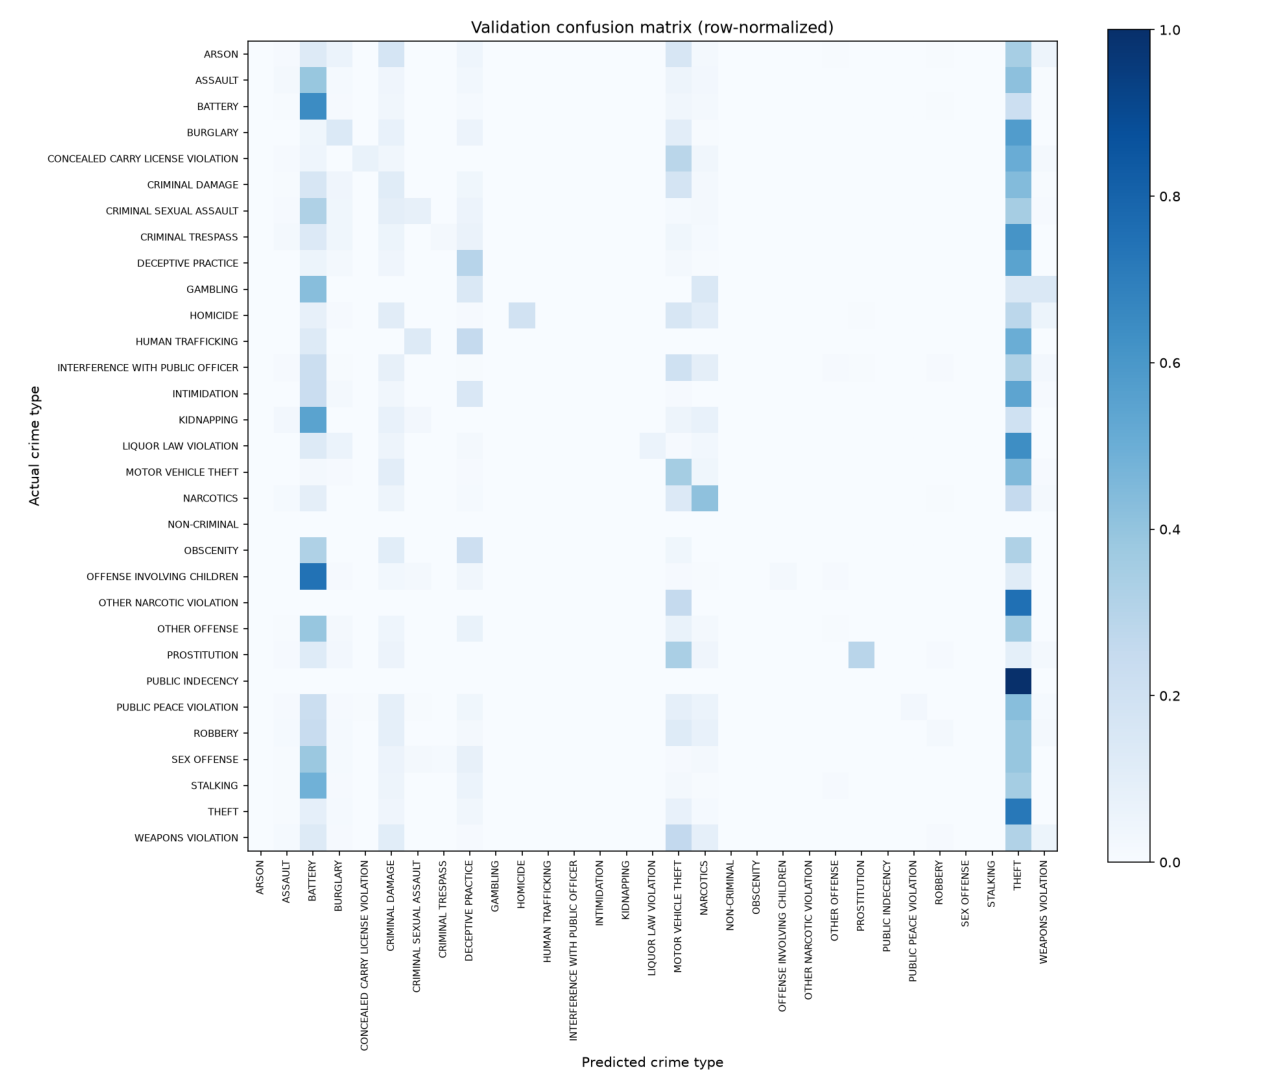

Strongest supported class: BATTERY (F1=0.541).
Weakest supported class: ARSON (F1=0.000, support=182).
Largest error pair: CRIMINAL DAMAGE predicted as THEFT (6113 rows).
Compare macro and weighted F1: common classes can conceal weak rare-class performance.


In [50]:
display(pd.DataFrame(sorted((k, str(v)) for k, v in model.get_params().items()), columns=["parameter", "value"]))
gap = train["macro_f1"] - val["macro_f1"]
print(f"Train macro F1 {train['macro_f1']:.3f} | validation macro F1 {val['macro_f1']:.3f} | gap {gap:.3f}")
print("Five least frequent validation classes (low recall here shows the class-imbalance effect):")
display(per_class.loc[per_class.support > 0].nsmallest(5, "support"))
display(per_class)
show_confusion(directory / "validation_confusion_matrix.png")
print(interpretation(per_class, cm))

## 14. Findings / conclusion
**Algorithm-specific notes.** Strengths: interpretable linear multiclass baseline, fast to score, stable. Weaknesses: linear boundaries cannot model location x time interactions; SAGA can converge slowly; rare classes are usually under-predicted.

**My observed results (complete after running):** state train vs validation macro F1 and the gap, the weakest and least frequent classes, and the largest confusion pair printed above.

Use the displayed scores and error pairs in your report. A large training/validation gap
can indicate overfitting; a weighted/macro F1 gap can reveal weak rare-class performance.
Notebook 11 compares all four completed baselines. Notebook 12 tunes the leading candidates.
A convergence warning must be reviewed before selecting that candidate.